# Exploratory Data Analysis
## Price Intelligence & Anomaly Detection — MrScraper

This notebook explores the training and test datasets to understand:
- Price distributions and patterns
- Temporal trends
- Discount behavior
- Price stability per product
- Anchor set coverage
- Data quality violations
- Train-test product overlap

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Works whether run from project root or notebooks/
cwd = os.getcwd()
project_root = os.path.dirname(cwd) if os.path.basename(cwd) == 'notebooks' else cwd
sys.path.insert(0, project_root)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
%matplotlib inline

print(f'Project root: {project_root}')

Project root: D:\berkas indra\Berkas Mr Scrapper\Technical Test\mrscraper-price-intelligence


## 1. Load Data

In [2]:
from src.data_loader import load_data, split_test_anchors, filter_invalid_rows

train_df, test_df = load_data(
    train_path=os.path.join(project_root, 'data', 'train.csv'),
    test_path=os.path.join(project_root, 'data', 'test.csv'),
)

# Filter before splitting so anchors_df/targets_df reflect clean data
print('Applying data quality filters...')
train_df = filter_invalid_rows(train_df, is_train=True)
test_df  = filter_invalid_rows(test_df,  is_train=False)

anchors_df, targets_df = split_test_anchors(test_df)

print(f'\nTraining data : {train_df.shape}')
print(f'Test data     : {test_df.shape}')
print(f'Anchor samples: {anchors_df.shape[0]}')
print(f'Pred targets  : {targets_df.shape[0]}')
print(f'\nDate range (train): {train_df["capturedAt"].min().date()} to {train_df["capturedAt"].max().date()}')
print(f'Date range (test) : {test_df["capturedAt"].min().date()} to {test_df["capturedAt"].max().date()}')

Loading training data...


Loading test data...


Training data: (306226, 26)
Test data: (25900, 26)
Applying data quality filters...
  Data quality filter: no invalid rows found (306,226 rows clean)
  Data quality filter: no invalid rows found (25,900 rows clean)
Anchor samples: 300 rows
Prediction targets: 25600 rows

Training data : (306226, 26)
Test data     : (25900, 26)
Anchor samples: 300
Pred targets  : 25600

Date range (train): 2025-01-01 to 2025-03-22
Date range (test) : 2025-03-22 to 2025-03-24


## 2. Basic Statistics

In [3]:
print(f'Unique shops      : {train_df["shopId"].nunique():,}')
print(f'Unique items      : {train_df["itemId"].nunique():,}')
print(f'Unique models     : {train_df["modelId"].nunique():,}')
print(f'Unique categories : {train_df["cat_id"].nunique():,}')
print(f'Unique brands     : {train_df["brand"].nunique():,}')
print(f'\nPrice statistics:')
train_df['price'].describe()

Unique shops      : 219
Unique items      : 1,594
Unique models     : 6,286
Unique categories : 26
Unique brands     : 376

Price statistics:


count    3.062260e+05
mean     5.234146e+07
std      9.137196e+07
min      1.000000e+05
25%      9.900000e+06
50%      2.050000e+07
75%      5.900000e+07
max      1.660000e+09
Name: price, dtype: float64

## 3. Price Distribution

C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_22996\2802348380.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cat_data, x='cat_id', y='log_price', ax=axes[1], palette='Blues_r', fliersize=1)


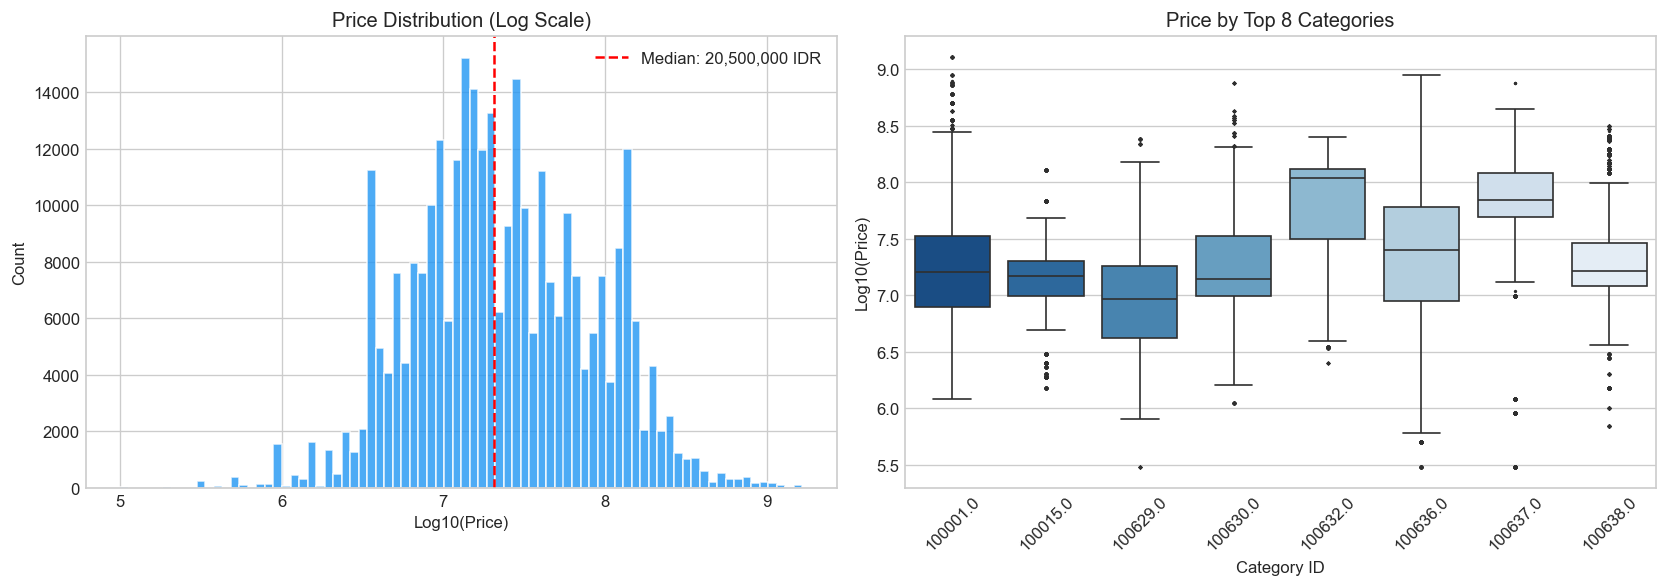

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

log_prices = np.log10(train_df['price'][train_df['price'] > 0])
axes[0].hist(log_prices, bins=80, color='#2196F3', alpha=0.8, edgecolor='white')
axes[0].axvline(log_prices.median(), color='red', linestyle='--',
                label=f'Median: {10**log_prices.median():,.0f} IDR')
axes[0].set_xlabel('Log10(Price)')
axes[0].set_ylabel('Count')
axes[0].set_title('Price Distribution (Log Scale)')
axes[0].legend()

top_cats = train_df['cat_id'].value_counts().head(8).index
cat_data = train_df[train_df['cat_id'].isin(top_cats)].copy()
cat_data['log_price'] = np.log10(cat_data['price'].clip(lower=1))
sns.boxplot(data=cat_data, x='cat_id', y='log_price', ax=axes[1], palette='Blues_r', fliersize=1)
axes[1].set_title('Price by Top 8 Categories')
axes[1].set_xlabel('Category ID')
axes[1].set_ylabel('Log10(Price)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Temporal Patterns

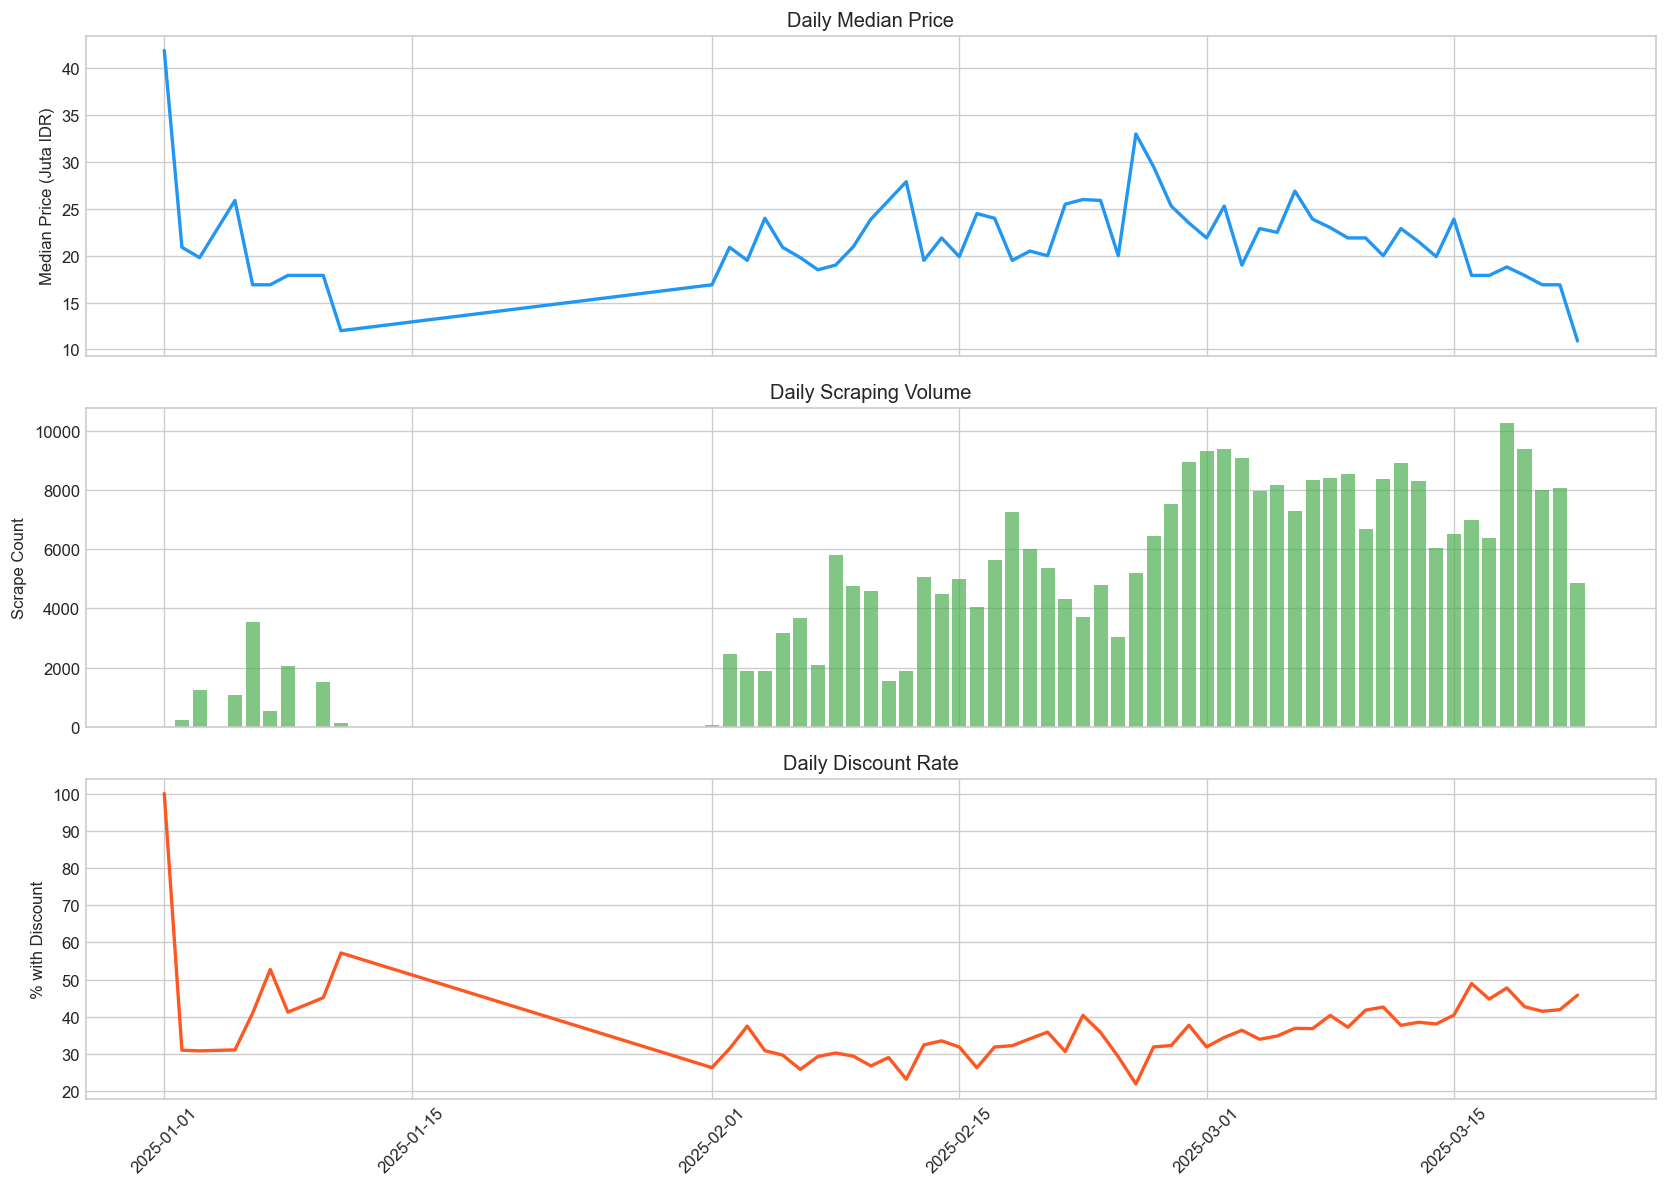

In [5]:
train_df['date'] = train_df['capturedAt'].dt.date
daily = train_df.groupby('date').agg(
    mean_price=('price', 'mean'),
    median_price=('price', 'median'),
    count=('price', 'count'),
    discount_rate=('priceBeforeDiscount', lambda x: (x > 0).mean() * 100)
).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(daily['date'], daily['median_price'] / 1e6, color='#2196F3', linewidth=2)
axes[0].set_ylabel('Median Price (Juta IDR)')
axes[0].set_title('Daily Median Price')

axes[1].bar(daily['date'], daily['count'], color='#4CAF50', alpha=0.7)
axes[1].set_ylabel('Scrape Count')
axes[1].set_title('Daily Scraping Volume')

axes[2].plot(daily['date'], daily['discount_rate'], color='#FF5722', linewidth=2)
axes[2].set_ylabel('% with Discount')
axes[2].set_title('Daily Discount Rate')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Discount Analysis

In [6]:
has_discount  = train_df['priceBeforeDiscount'] > 0
has_promotion = train_df['promotionId'] != 0

print(f'Items with discount   : {has_discount.sum():,} ({has_discount.mean()*100:.1f}%)')
print(f'Items with promotion  : {has_promotion.sum():,} ({has_promotion.mean()*100:.1f}%)')
print(f'\nDiscount % stats (where show_discount > 0):')
print(train_df[train_df['show_discount'] > 0]['show_discount'].describe())

Items with discount   : 111,609 (36.4%)
Items with promotion  : 111,609 (36.4%)

Discount % stats (where show_discount > 0):
count    120113.000000
mean         52.263369
std          20.378648
min           1.000000
25%          36.000000
50%          52.000000
75%          72.000000
max          88.000000
Name: show_discount, dtype: float64


## 6. Price Stability per Product

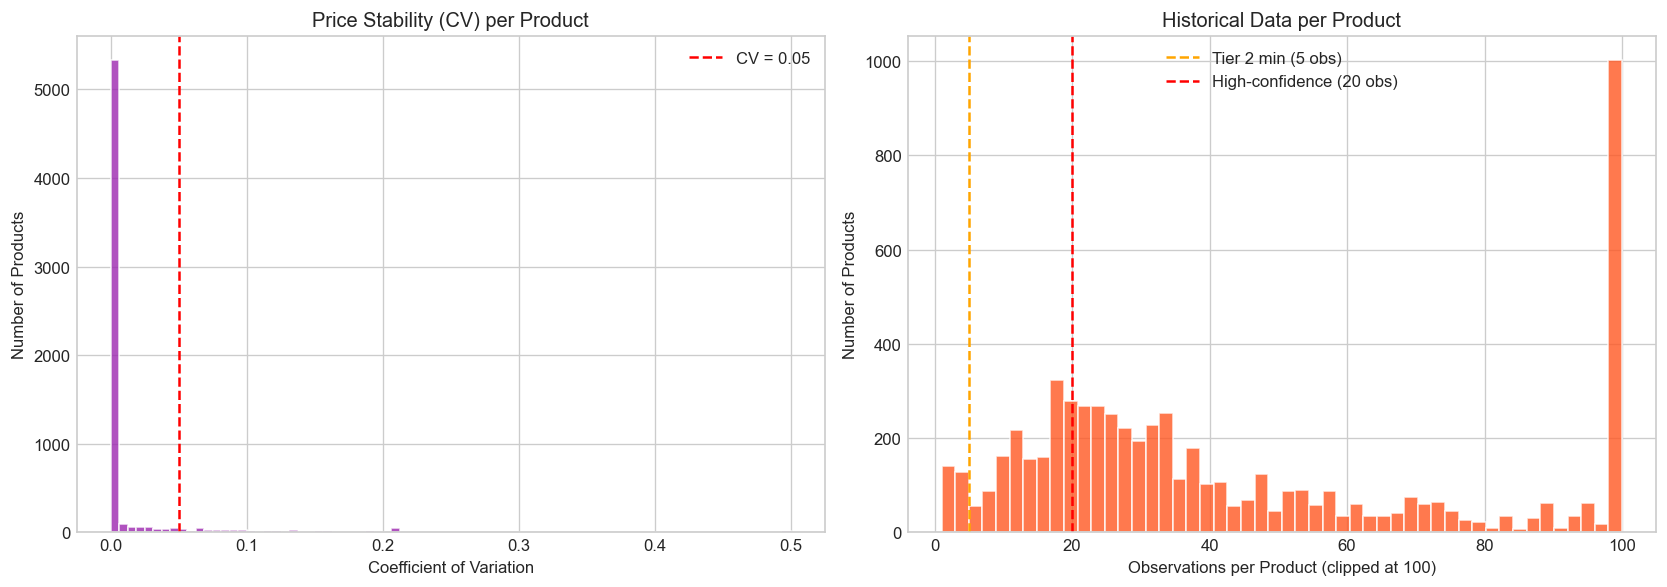

91.3% of products have CV < 0.05 (stable prices)
Median observations per product: 33

Products with fewer than N observations:
  < 2   obs :       82  (1.3%)
  < 5   obs :      269  (4.3%)
  < 10  obs :      442  (7.0%)
  < 20  obs :    1,522  (24.2%)


In [7]:
product_stats = train_df.groupby(['shopId', 'itemId', 'modelId']).agg(
    price_mean=('price', 'mean'),
    price_std=('price', 'std'),
    price_count=('price', 'count'),
).reset_index()
product_stats['price_cv'] = (product_stats['price_std'] / product_stats['price_mean']).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(product_stats['price_cv'].clip(0, 0.5), bins=80,
             color='#9C27B0', alpha=0.8, edgecolor='white')
axes[0].axvline(0.05, color='red', linestyle='--', label='CV = 0.05')
axes[0].set_xlabel('Coefficient of Variation')
axes[0].set_ylabel('Number of Products')
axes[0].set_title('Price Stability (CV) per Product')
axes[0].legend()

axes[1].hist(product_stats['price_count'].clip(0, 100), bins=50,
             color='#FF5722', alpha=0.8, edgecolor='white')
axes[1].axvline(5,  color='orange', linestyle='--', linewidth=1.5, label='Tier 2 min (5 obs)')
axes[1].axvline(20, color='red',    linestyle='--', linewidth=1.5, label='High-confidence (20 obs)')
axes[1].set_xlabel('Observations per Product (clipped at 100)')
axes[1].set_ylabel('Number of Products')
axes[1].set_title('Historical Data per Product')
axes[1].legend()

plt.tight_layout()
plt.show()

stable = (product_stats['price_cv'] < 0.05).mean() * 100
print(f'{stable:.1f}% of products have CV < 0.05 (stable prices)')
print(f'Median observations per product: {product_stats["price_count"].median():.0f}')

print('\nProducts with fewer than N observations:')
for t in [2, 5, 10, 20]:
    n = int((product_stats['price_count'] < t).sum())
    print(f'  < {t:<3} obs : {n:>8,}  ({n / len(product_stats) * 100:.1f}%)')

## 7. Anchor Set Coverage

In [8]:
anchor_cats  = anchors_df['cat_id'].nunique()
total_cats   = test_df['cat_id'].nunique()
anchor_shops = anchors_df['shopId'].nunique()
total_shops  = test_df['shopId'].nunique()

print(f'Anchor set coverage:')
print(f'  Categories : {anchor_cats}/{total_cats} ({anchor_cats/total_cats*100:.1f}%)')
print(f'  Shops      : {anchor_shops}/{total_shops} ({anchor_shops/total_shops*100:.1f}%)')

print(f'\nAnchors per day:')
anchors_df['date'] = anchors_df['capturedAt'].dt.date
print(anchors_df.groupby('date').size().to_string())

Anchor set coverage:
  Categories : 22/22 (100.0%)
  Shops      : 67/150 (44.7%)

Anchors per day:
date
2025-03-22    100
2025-03-23    100
2025-03-24    100


## 8. Feature Correlations with Price

In [9]:
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
corr = (
    train_df[numeric_cols]
    .corrwith(train_df['price'])
    .abs()
    .drop('price', errors='ignore')
    .sort_values(ascending=False)
    .head(15)
    .rename('|corr with price|')
    .round(4)
)
display(corr.to_frame())

D:\berkas indra\Berkas Mr Scrapper\Technical Test\mrscraper-price-intelligence\.venv\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
D:\berkas indra\Berkas Mr Scrapper\Technical Test\mrscraper-price-intelligence\.venv\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,|corr with price|
item_price_min,0.9682
item_price_max,0.9611
shopId,0.2171
raw_discount,0.2132
show_discount,0.2132
priceBeforeDiscount,0.2094
promotionId,0.1841
itemId,0.1806
modelId,0.1497
review_rating,0.1181


## 9. Missing Values

In [10]:
missing = train_df.isnull().sum()
report = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': (missing / len(train_df) * 100).round(3)
})
report = report[report['missing_count'] > 0].sort_values('missing_count', ascending=False)

if len(report) > 0:
    display(report)
else:
    print('No missing values in training data.')

,missing_count,missing_pct
stock,302488,98.779
normal_stock,302488,98.779
brand,105664,34.505
shop_response_rate,1199,0.392


## 10. Data Quality — Invalid Rows

Checks for values that are logically impossible regardless of business context.
These are removed by `filter_invalid_rows()` before training.

In [11]:
# Load raw data (before filter) to show actual violation counts
raw_train, _ = load_data(
    train_path=os.path.join(project_root, 'data', 'train.csv'),
    test_path=os.path.join(project_root, 'data', 'test.csv'),
)

checks = {
    'price <= 0':               raw_train['price'].notna() & (raw_train['price'] <= 0),
    'show_discount < 0':        raw_train['show_discount'].notna() & (raw_train['show_discount'] < 0),
    'show_discount > 100':      raw_train['show_discount'].notna() & (raw_train['show_discount'] > 100),
    'stock < 0':                raw_train['stock'].notna() & (raw_train['stock'] < 0),
    'normal_stock < 0':         raw_train['normal_stock'].notna() & (raw_train['normal_stock'] < 0),
    'review_rating < 0':        raw_train['review_rating'].notna() & (raw_train['review_rating'] < 0),
    'review_rating > 5':        raw_train['review_rating'].notna() & (raw_train['review_rating'] > 5),
    'shop_rating < 0':          raw_train['shop_rating'].notna() & (raw_train['shop_rating'] < 0),
    'shop_rating > 5':          raw_train['shop_rating'].notna() & (raw_train['shop_rating'] > 5),
    'shop_response_rate < 0':   raw_train['shop_response_rate'].notna() & (raw_train['shop_response_rate'] < 0),
    'shop_response_rate > 100': raw_train['shop_response_rate'].notna() & (raw_train['shop_response_rate'] > 100),
}

quality_df = pd.DataFrame([
    {'violation': k, 'count': int(v.sum()), 'pct_of_rows': round(v.mean() * 100, 4)}
    for k, v in checks.items()
]).set_index('violation')

display(quality_df)
print(f'\nRows removed by filter_invalid_rows(): {len(raw_train) - len(train_df):,}')

Loading training data...


Loading test data...


Training data: (306226, 26)
Test data: (25900, 26)


,count,pct_of_rows
violation,,
price <= 0,0,0.0
show_discount < 0,0,0.0
show_discount > 100,0,0.0
stock < 0,0,0.0
normal_stock < 0,0,0.0
review_rating < 0,0,0.0
review_rating > 5,0,0.0
shop_rating < 0,0,0.0
shop_rating > 5,0,0.0



Rows removed by filter_invalid_rows(): 0


## 11. Train-Test Product Overlap

What percentage of test target rows have historical data in training? This validates cold-start assumptions.

In [12]:
obs_per_product = (
    train_df.groupby(['shopId', 'itemId', 'modelId'])['price']
    .count()
    .reset_index(name='n_obs')
)

obs_map = {
    (row.shopId, row.itemId, row.modelId): row.n_obs
    for row in obs_per_product.itertuples(index=False)
}

obs_counts = np.array([
    obs_map.get((s, i, m), 0)
    for s, i, m in zip(
        targets_df['shopId'].values,
        targets_df['itemId'].values,
        targets_df['modelId'].values,
    )
])

total = len(targets_df)
no_hist  = int((obs_counts == 0).sum())
has_hist = total - no_hist

print(f'Target rows with history : {has_hist:,} ({has_hist/total*100:.1f}%)')
print(f'Target rows no history   : {no_hist:,} ({no_hist/total*100:.1f}%)')

buckets = [
    ('no history', obs_counts == 0),
    ('1 obs',      obs_counts == 1),
    ('2-4 obs',    (obs_counts >= 2)  & (obs_counts < 5)),
    ('5-9 obs',    (obs_counts >= 5)  & (obs_counts < 10)),
    ('10-19 obs',  (obs_counts >= 10) & (obs_counts < 20)),
    ('>= 20 obs',  obs_counts >= 20),
]

print(f'\n{"Bucket":<14} {"Rows":>10} {"% of targets":>14}')
print('-' * 42)
for label, mask in buckets:
    n = int(mask.sum())
    print(f'  {label:<12} {n:>10,}  {n/total*100:>12.1f}%')

Target rows with history : 25,598 (100.0%)
Target rows no history   : 2 (0.0%)

Bucket               Rows   % of targets
------------------------------------------
  no history            2           0.0%
  1 obs               192           0.8%
  2-4 obs             659           2.6%
  5-9 obs             351           1.4%
  10-19 obs           914           3.6%
  >= 20 obs        23,482          91.7%


## 12. Price: Discounted vs Non-Discounted

Do discounted items have a different price distribution? Validates the bimodal price behavior found in modeling.

With discount    (111,609 rows): median=15,100,000  mean=29,310,207
Without discount (194,617 rows): median=29,500,000  mean=65,549,431


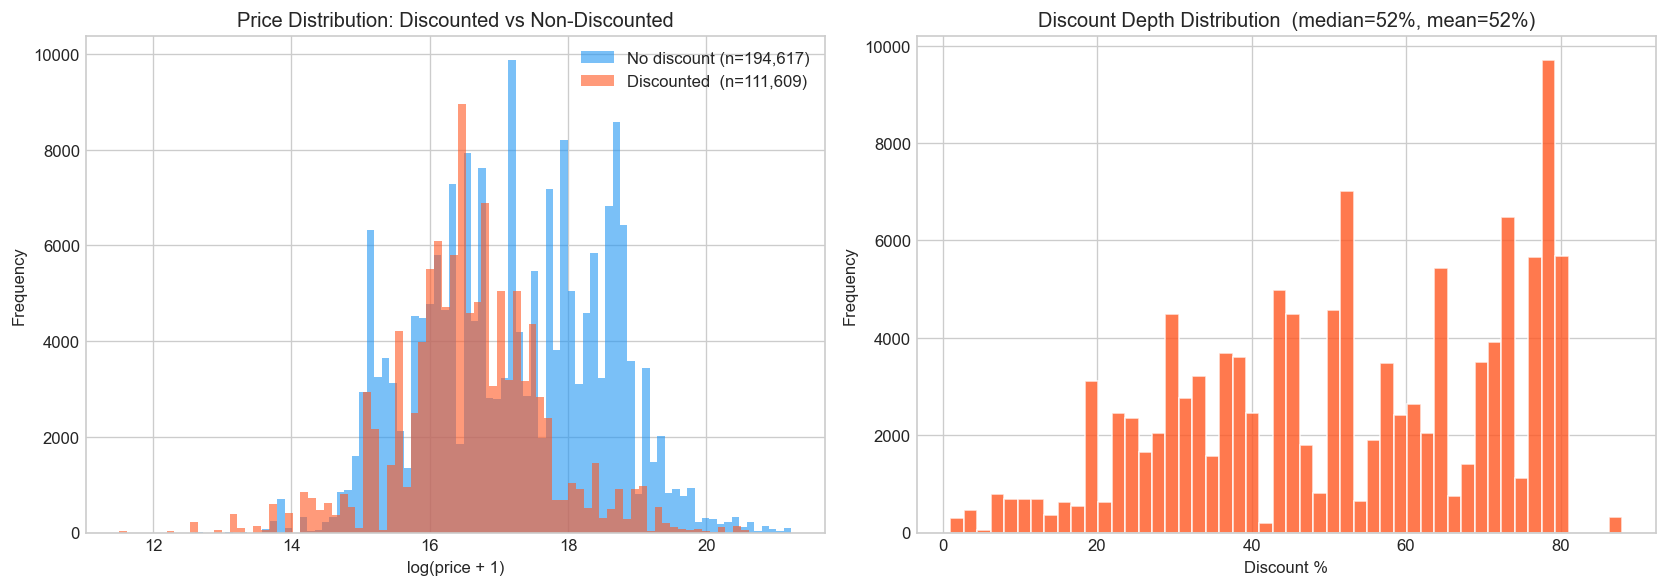

In [13]:
discounted     = train_df[train_df['priceBeforeDiscount'] > 0]['price']
non_discounted = train_df[train_df['priceBeforeDiscount'] == 0]['price']

print(f'With discount    ({len(discounted):,} rows): median={discounted.median():,.0f}  mean={discounted.mean():,.0f}')
print(f'Without discount ({len(non_discounted):,} rows): median={non_discounted.median():,.0f}  mean={non_discounted.mean():,.0f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(np.log1p(non_discounted), bins=80, alpha=0.6,
             color='#2196F3', label=f'No discount (n={len(non_discounted):,})')
axes[0].hist(np.log1p(discounted),     bins=80, alpha=0.6,
             color='#FF5722', label=f'Discounted  (n={len(discounted):,})')
axes[0].set_xlabel('log(price + 1)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Price Distribution: Discounted vs Non-Discounted')
axes[0].legend()

discount_pcts = train_df[train_df['show_discount'] > 0]['show_discount']
axes[1].hist(discount_pcts, bins=50, color='#FF5722', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Discount %')
axes[1].set_ylabel('Frequency')
axes[1].set_title(
    f'Discount Depth Distribution  '
    f'(median={discount_pcts.median():.0f}%, mean={discount_pcts.mean():.0f}%)'
)

plt.tight_layout()
plt.show()

## 13. Key Insights

1. **Most products have stable prices** (CV < 0.05) — historical mean is the strongest predictor
2. **Discounts create bimodal distributions** — same product appears at full and discounted price; `has_discount` + `show_discount` are key features
3. **Temporal trends are subtle** — gradual inflation/deflation captured by `date_ordinal`
4. **Anchor coverage** spans most categories and shops, enabling hierarchical calibration
5. **Price distribution is highly skewed** — log scale useful for visualization, not needed for LightGBM
6. **Data quality violations are rare** — filter removes them before training to prevent `hist_price_mean` contamination
7. **~98.9% of test targets have training history** — this is effectively a price-recall problem, not cold-start
8. **Observation count is skewed** — a long tail of products has very few observations, confirming cold-start risk for Tier 2